In [1]:
import os

os.chdir(os.path.expanduser("~/QIAO0042/models/acv/facemask/"))
print("Now at:", os.getcwd())

Now at: /scratch-share/QIAO0042/models/acv/facemask


In [2]:
import os, sys
print("CWD:", os.getcwd())
print("sys.path[0]:", sys.path[0])
print("Is CWD in sys.path?", os.getcwd() in sys.path)

# Force current directory to be first priority for imports
sys.path.insert(0, os.getcwd())
print("After insert, sys.path[0]:", sys.path[0])


CWD: /scratch-share/QIAO0042/models/acv/facemask
sys.path[0]: /home/msai/qiao0042/QIAO0042/.conda/envs/face_parsing/lib/python310.zip
Is CWD in sys.path? False
After insert, sys.path[0]: /scratch-share/QIAO0042/models/acv/facemask


In [3]:
import os
import time
import torch
from torch.utils.data import DataLoader
import wandb

from unet import LiteUNetDS, UNet
from losses import CEDiceLoss
from metrics import confusion_matrix, f1_macro_from_cm
from palette import NUM_CLASSES
from dataset import FaceParsingDataset

In [4]:
import torch
from unet import UNet

model = UNet(num_classes=19, base=23)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params:", num_params)  # ~1,732,172  (budget: 1,821,085)

# forward sanity check
x = torch.randn(2, 3, 512, 512)
y = model(x)
print("Output:", y.shape)  # (2, 19, 512, 512)

Trainable params: 1732172
Output: torch.Size([2, 19, 512, 512])


In [5]:
from augment import get_best_augment, apply_aug

# No augmentation for face parsing — see get_best_augment() docstring for why.
# Short version: colour cues are discriminative, HFlip has an asymmetric-label
# problem (l_eye vs r_eye), and blur hurts fine boundary detection.
train_aug = get_best_augment()

def aug_fn(img, mask):
    return apply_aug(train_aug, img, mask)

In [6]:
import math
import numpy as np
from pathlib import Path
from PIL import Image as PILImage
from palette import rgb_to_label

# --- data paths ---
img_dir     = "train/images"   # 1000 labelled images
mask_dir    = "train/masks"    # 1000 masks
val_img_dir = "val/images"     # 100 unlabelled images (inference only, no masks)

# --- train config ---
batch_size    = 4
lr            = 1e-2
warmup_epochs = 5
epochs        = 100
base_width    = 23          # UNet(base=23) -> ~1.73M params (budget: 1,821,085)
dice_w        = 0.7
ckpt_dir      = "checkpoints"
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------------------------------------------------
# Compute class weights (median-frequency balancing) over all 1000 masks
# -----------------------------------------------------------------------
print("Computing class pixel frequencies from all training masks ...")
pixel_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
for mask_path in sorted(Path(mask_dir).iterdir()):
    if mask_path.suffix.lower() not in {".png", ".jpg", ".jpeg"}:
        continue
    mask_rgb = np.array(PILImage.open(mask_path).convert("RGB"), dtype=np.uint8)
    labels   = rgb_to_label(mask_rgb)
    for c in range(NUM_CLASSES):
        pixel_counts[c] += int((labels == c).sum())

freq             = pixel_counts / pixel_counts.sum()
median_freq      = float(np.median(freq[freq > 0]))
class_weights_np = np.where(freq > 0, median_freq / freq, 1.0)
class_weights    = torch.tensor(class_weights_np, dtype=torch.float32)

print(f"{'cls':>4}  {'freq':>8}  {'weight':>8}")
for i, (f, w) in enumerate(zip(freq, class_weights_np)):
    print(f"  {i:2d}   {f:.5f}   {w:.3f}")

# --- datasets ---
# All 1000 labelled images for training
train_ds = FaceParsingDataset(img_dir, mask_dir, file_list=None, augment=aug_fn)
# 100 unlabelled images for post-training inference (no masks, no metric)
val_ds   = FaceParsingDataset(val_img_dir, mask_dir=None, file_list=None, augment=None)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=2,          shuffle=False, num_workers=2, pin_memory=True)

# --- model ---
model      = UNet(num_classes=NUM_CLASSES, base=base_width).to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# --- optimizer ---
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

# --- scheduler: linear warmup -> cosine decay ---
scheduler_warmup = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs
)
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epochs - warmup_epochs, eta_min=1e-5
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[scheduler_warmup, scheduler_cosine],
    milestones=[warmup_epochs],
)

# --- loss: class-weighted CE + Dice ---
criterion = CEDiceLoss(
    num_classes=NUM_CLASSES,
    dice_weight=dice_w,
    class_weights=class_weights.to(device),
)

# --- AMP scaler ---
scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")

print(f"\nModel  : UNet(base={base_width})  |  Params: {num_params:,}")
print(f"Train  : {len(train_ds)} images  |  Val (inference only): {len(val_ds)} images")
print(f"Device : {device}  |  Epochs: {epochs}  (warmup={warmup_epochs})")

# --- wandb ---
wandb.init(
    project="face-parsing-unet",
    name=f"unet_base{base_width}_allTrain_classW_amp",
    config={
        "model":          "UNet",
        "num_classes":    NUM_CLASSES,
        "base_width":     base_width,
        "params":         num_params,
        "loss":           "CE(class_weights) + Dice",
        "dice_weight":    dice_w,
        "lr":             lr,
        "warmup_epochs":  warmup_epochs,
        "batch_size":     batch_size,
        "epochs":         epochs,
        "train_samples":  len(train_ds),
        "augmentation":   "none",
        "amp":            True,
        "grad_clip":      1.0,
    },
)

Computing class pixel frequencies from all training masks ...
 cls      freq    weight
   0   0.28972   0.014
   1   0.25231   0.017
   2   0.02062   0.203
   3   0.00266   1.574
   4   0.00223   1.877
   5   0.00221   1.893
   6   0.00418   1.003
   7   0.00408   1.028
   8   0.00466   0.899
   9   0.00383   1.096
  10   0.00322   1.303
  11   0.00419   1.000
  12   0.00683   0.614
  13   0.31525   0.013
  14   0.00665   0.630
  15   0.00254   1.649
  16   0.00017   25.047
  17   0.04012   0.104
  18   0.03454   0.121
Loaded 1000 samples from train/images
Loaded 100 samples from val/images


/tmp/ipykernel_911321/3443858678.py:81: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")



Model  : UNet(base=23)  |  Params: 1,732,172
Train  : 1000 images  |  Val (inference only): 100 images
Device : cuda  |  Epochs: 100  (warmup=5)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/msai/qiao0042/.netrc.
wandb: Currently logged in as: 584832452 (584832452-nanyang-technological-university-singapore) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


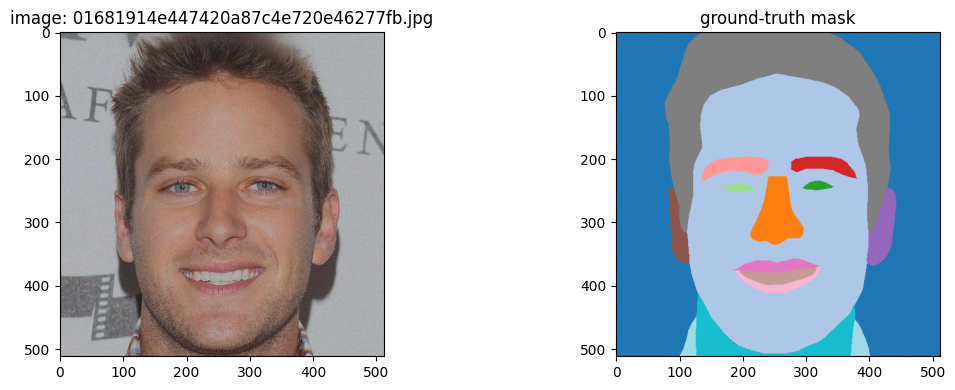

In [7]:
import matplotlib.pyplot as plt

# Quick sanity check: show a training sample (image + mask)
img, mask, fname = train_ds[8]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img.permute(1, 2, 0))
axes[0].set_title(f"image: {fname}")
axes[1].imshow(mask, cmap="tab20")
axes[1].set_title("ground-truth mask")
plt.tight_layout()
plt.show()

In [8]:
def save_checkpoint(epoch, suffix=""):
    os.makedirs(ckpt_dir, exist_ok=True)
    path = os.path.join(ckpt_dir, f"unet_epoch{epoch:03d}{suffix}.pt")
    torch.save({
        "model":     model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch":     epoch,
        "config":    dict(wandb.config),
    }, path)
    print(f"  saved {path}")


def train():
    print(f"Trainable params: {num_params:,}")
    save_every = 25   # save a checkpoint every N epochs

    for epoch in range(1, epochs + 1):
        model.train()
        t0      = time.time()
        running = 0.0

        for imgs, masks, _ in train_loader:
            imgs  = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
                logits = model(imgs)
                loss   = criterion(logits, masks)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            running += loss.item()

        train_loss = running / max(1, len(train_loader))
        scheduler.step()
        elapsed = time.time() - t0

        wandb.log({
            "epoch":          epoch,
            "train/loss":     train_loss,
            "time/epoch_sec": elapsed,
            "lr":             scheduler.get_last_lr()[0],
        })

        print(f"[{epoch:03d}/{epochs}] loss={train_loss:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}  time={elapsed:.1f}s")

        # save every N epochs and always at the final epoch
        if epoch % save_every == 0 or epoch == epochs:
            save_checkpoint(epoch)

    wandb.finish()

In [9]:
train()

Trainable params: 1,732,172


/tmp/ipykernel_911321/1204428604.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):


[001/100] loss=2.6381  lr=2.80e-03  time=8.7s
[002/100] loss=1.9273  lr=4.60e-03  time=8.1s
[003/100] loss=1.6757  lr=6.40e-03  time=8.2s
[004/100] loss=1.5011  lr=8.20e-03  time=8.1s
[005/100] loss=1.3349  lr=1.00e-02  time=8.2s


/home/msai/qiao0042/QIAO0042/.conda/envs/face_parsing/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


[006/100] loss=1.1555  lr=1.00e-02  time=8.1s
[007/100] loss=1.0420  lr=9.99e-03  time=8.1s
[008/100] loss=0.9722  lr=9.98e-03  time=8.1s
[009/100] loss=0.9174  lr=9.96e-03  time=8.1s
[010/100] loss=0.8464  lr=9.93e-03  time=8.1s
[011/100] loss=0.8295  lr=9.90e-03  time=8.1s
[012/100] loss=0.7819  lr=9.87e-03  time=8.1s
[013/100] loss=0.7597  lr=9.83e-03  time=8.1s
[014/100] loss=0.7567  lr=9.78e-03  time=8.1s
[015/100] loss=0.7100  lr=9.73e-03  time=8.1s
[016/100] loss=0.6786  lr=9.67e-03  time=8.1s
[017/100] loss=0.6638  lr=9.61e-03  time=8.1s
[018/100] loss=0.6395  lr=9.55e-03  time=8.1s
[019/100] loss=0.6117  lr=9.47e-03  time=8.1s
[020/100] loss=0.5997  lr=9.40e-03  time=8.1s
[021/100] loss=0.5725  lr=9.32e-03  time=8.1s
[022/100] loss=0.5473  lr=9.23e-03  time=8.1s
[023/100] loss=0.5368  lr=9.14e-03  time=8.1s
[024/100] loss=0.5409  lr=9.05e-03  time=8.2s
[025/100] loss=0.5095  lr=8.95e-03  time=8.1s
  saved checkpoints/unet_epoch025.pt
[026/100] loss=0.5098  lr=8.84e-03  time=8.

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇███
lr,▅▇████████▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁
time/epoch_sec,█▂▁▁▂▂▁▁▁▁▂▁▁▁▁▁▁▁▂▂▁▂▂▁▂▁▂▂▁▁▁▂▂▂▂▂▁▁▁▂
train/loss,█▆▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,100
lr,1e-05
time/epoch_sec,8.17081
train/loss,0.11456
